In [ ]:
import sys
import os
print(os.getcwd())
sys.path.append(os.getcwd())
from utils import data_visualization as dv
from utils import simulation_utils as su
from utils import local_models as lm
from utils import fcla as fc
from utils import apis as pi



c:\Users\alejo\Desktop\intro_la_inv


Collab setup

In [ ]:
import sys
import glob
import os
#!pip install uv
#!uv sync
#venv_path = glob.glob(".venv/lib/python*/site-packages")
#if venv_path:
#    sys.path.insert(0, os.path.abspath(venv_path[0]))
#    print(f"Successfully linked uv environment: {venv_path[0]}")
#else:
#    print("Could not find the .venv folder. Did uv sync run successfully?")

# LLm model tests


## 1. Local Models


## 1.1 Download the model weigths

In [ ]:

repo_id = "Qwen/Qwen3.5-4B" 
#lm.download_models(repo_id)


Iniciando descarga de Qwen/Qwen3.5-4B en la carpeta ./models/modelo_qwen_4b...


c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Fetching 14 files: 100%|██████████| 14/14 [06:49<00:00, 29.26s/it]

¡Descarga completada con éxito!


## 1.2 Load and Test llm models

In [1]:
from utils import local_models as lm
model_name = "modelo_qwen_4b"
model_q,tokenizer_q = lm.load_model(model_name,hardware_profile="laptop_gtx")
print(model_q)

c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU Detectada: NVIDIA GeForce GTX 1650 | VRAM Aprox: 4.29 GB
Cargando perfil estricto: Laptop GTX (4-bits, nf4)
Cargando tokenizador desde ./models/modelo_qwen_4b...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Cargando pesos del modelo...


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 426/426 [00:18<00:00, 22.57it/s]


¡Modelo cargado exitosamente! Ubicación de tensores: cuda:0
Qwen3_5ForCausalLM(
  (model): Qwen3_5TextModel(
    (embed_tokens): Embedding(248320, 2560)
    (layers): ModuleList(
      (0-2): 3 x Qwen3_5DecoderLayer(
        (linear_attn): Qwen3_5GatedDeltaNet(
          (act): SiLUActivation()
          (conv1d): Conv1d(8192, 8192, kernel_size=(4,), stride=(1,), padding=(3,), groups=8192, bias=False)
          (norm): Qwen3_5RMSNormGated()
          (out_proj): Linear4bit(in_features=4096, out_features=2560, bias=False)
          (in_proj_qkv): Linear4bit(in_features=2560, out_features=8192, bias=False)
          (in_proj_z): Linear4bit(in_features=2560, out_features=4096, bias=False)
          (in_proj_b): Linear4bit(in_features=2560, out_features=32, bias=False)
          (in_proj_a): Linear4bit(in_features=2560, out_features=32, bias=False)
        )
        (mlp): Qwen3_5MLP(
          (gate_proj): Linear4bit(in_features=2560, out_features=9216, bias=False)
          (up_proj): Li

In [3]:

prompt = f"""Eres un agente financiero llm en un mercado de doble subasta.
Tu sesgo cognitivo es: Eres un inversor agresivo con nula aversión al riesgo. Buscas ganancias masivas rápido y compras activos si el precio sube.
Datos actuales del mercado:precio:500, dinero 300..

REGLAS ESTRICTAS:
1. NO escribas introducciones ni conclusiones.
2. NO pienses en voz alta.
3. Tu justificación no puede exceder las 15 palabras.
4. Responde ÚNICAMENTE con un objeto JSON válido usando esta estructura exacta:
{{"justificacion": "breve motivo basado en tu sesgo", "accion": "COMPRAR" o "VENDER" o "MANTENER", "cantidad": entero}}
"""
model_conditions  ={"temperature":0.1,"max_tokens":2500,"min_tokens":500}
lm.test_local_llm(prompt,model_q,tokenizer_q,default_ps=model_conditions)


=== [DEBUG] RESPUESTA CRUDA DEL MODELO ===
Thinking Process:

1.  **Analyze the Request:**
    *   **Role:** Autonomous financial agent (LLM).
    *   **Market:** Double auction.
    *   **Cognitive Bias:** Aggressive investor, zero risk aversion. Seeks massive quick gains. Buys when price rises.
    *   **Current Market Data:** Price: 500, Money: 300.
    *   **Constraints:**
        1.  NO introductions or conclusions.
        2.  NO think aloud.
        3.  Justification must not exceed 15 words.
        4.  Response MUST be a valid JSON object.
        5.  JSON Structure: `{"justificacion": "...", "accion": "COMPRAR" or "VENDER" or "MANTENER", "cantidad": integer}`.
        *Wait, looking closer at the prompt:* The initial system instruction says: `{'precio', 'is_buy', 'volumen', 'razonamiento', 'emocion'}`. But the user instruction says: `{"justificacion": "...", "accion": "COMPRAR" or "VENDER" or "MANTENER", "cantidad": entero}`.
        *Conflict Resolution:* The user instructio

## 1.3 Ollama

In [ ]:
model = "qwen3:4b"
text = pi.test_llm(model,"ollama")
print(text)

[Ollama] Verificando/Descargando el modelo 'qwen3:4b'...
 -> Status: pulling manifest
 -> Status: pulling 3e4cb1417446
 -> Status: pulling 2d54db2b9bb2
 -> Status: pulling d18a5cc71b84
 -> Status: pulling cff3f395ef37
 -> Status: pulling e18a783aae55
 -> Status: verifying sha256 digest
 -> Status: writing manifest
 -> Status: success
[Ollama] Procesando tu consulta...
[Ollama RESPUESTA]: Loss aversion is a behavioral economics concept where individuals experience the psychological impact of losses more intensely than equivalent gains. In financial contexts, this often leads investors to:  
1. **Hold losing investments longer** (hoping to recover losses),  
2. **Sell winning investments prematurely** (to secure gains),  
3. **Avoid risky opportunities** due to fear of potential losses.  

This bias can distort decision-making, such as overreacting to market volatility or underestimating long-term growth potential. For example, during market downturns, loss-averse investors may panic-sel

## 1.4 Apis 


#### Groq

In [ ]:
model = "openai/gpt-oss-120b"
text = su.test_llm(model,"groq",api_key="")
print(text)

Simulation started. Type 'exit' to quit.

Agent: BUY

None


Nvidia


# Simulations

## 2.1 Classic simulations

In [8]:
j_dir = "./jsons/"
f_type = ".json"

{
    "simulation": {
        "markets": [
            "Market"
        ],
        "agents": [
            "FCNAgents"
        ],
        "sessions": [
            {
                "sessionName": 0,
                "iterationSteps": 100,
                "withOrderPlacement": true,
                "withOrderExecution": false,
                "withPrint": true,
                "hiFrequencySubmitRate": 1.0
            },
            {
                "sessionName": 1,
                "iterationSteps": 500,
                "withOrderPlacement": true,
                "withOrderExecution": true,
                "withPrint": false
            }
        ]
    },
    "Market": {
        "class": "Market",
        "tickSize": 0.05,
        "marketPrice": 290.0
    },
    "FCNAgents": {
        "class": "FCNAgent",
        "numAgents": 500,
        "markets": [
            "Market"
        ],
        "assetVolume": 10000,
        "cashAmount": 300000.0,
        "fundamentalWeight": {
           

c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\pams\market.py:746: UserWarning: order price does not accord to the tick size. price will be modified
  warnings.warn(


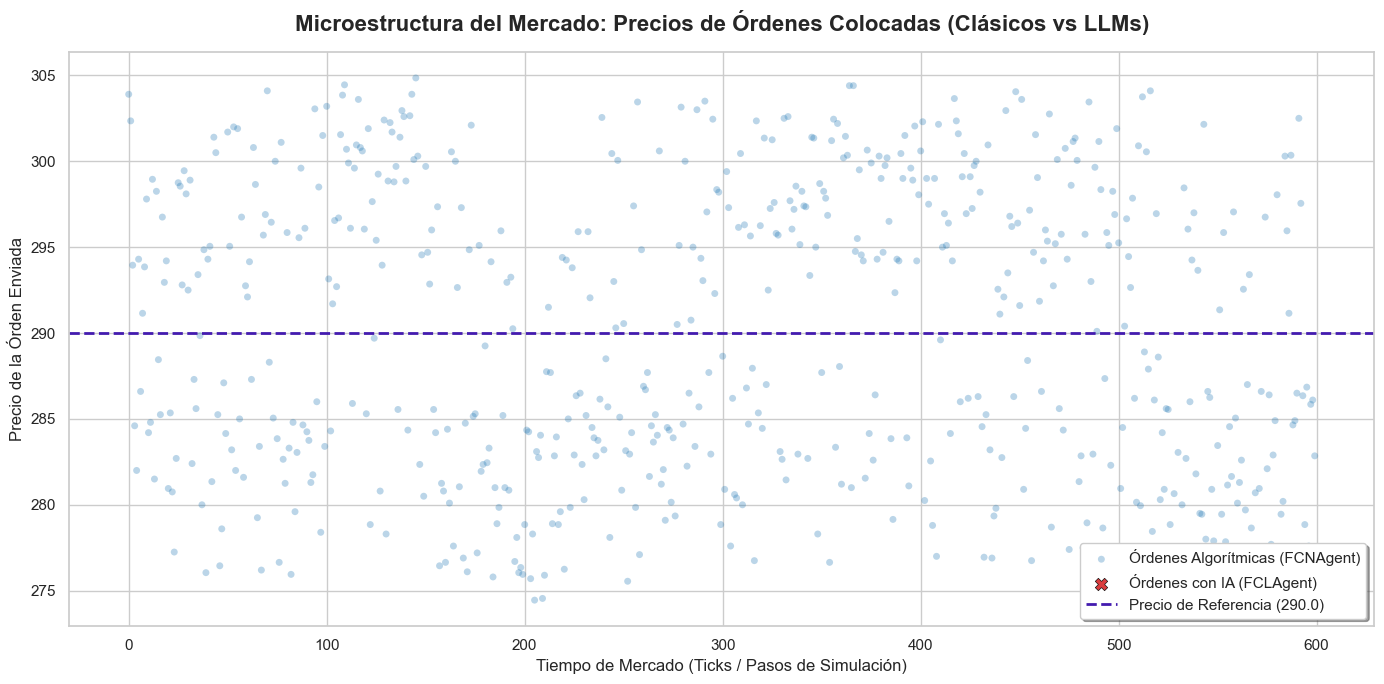

Columnas exportadas por PAMS: ['session_id', 'market_time', 'market_id', 'market_name', 'market_price', 'fundamental_price']


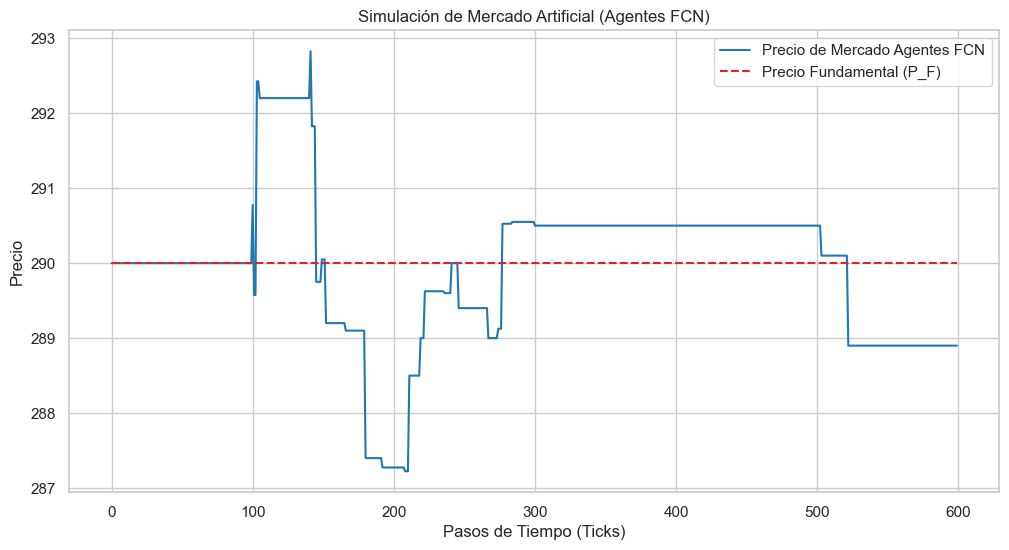

In [12]:
    
file_name = "llm_miter_500_config"

c_params_500 = {
    "iter_steps": [100, 500],  # ¡IMPORTANTE! 200 ticks de calentamiento para poblar el LOB
    "tickSize": 0.05, 
    "marketPrice": 290.0,       # Acércate al fundamental (o deja 250 pero aumenta el ruido abajo)
    "total_agents": 500, 
    "asset_vol": 10000, 
    "cash_am": 300000.0, 
    "mean_rev_time": [20, 50], 
    "time_window": [20, 40], 
    "order_margin": [0.01, 0.05], 
    "fundamental_price": 300.0
}


su.sim_loop(file_name,c_params_500, hybrid=False)


## 2.1 Simulation with llms 

### 2.1.1 ollama

In [ ]:

c_params_500 = {
    "iter_steps": [1, 500],  # ¡IMPORTANTE! 200 ticks de calentamiento para poblar el LOB
    "tickSize": 0.05, 
    "marketPrice": 290.0,       # Acércate al fundamental (o deja 250 pero aumenta el ruido abajo)
    "total_agents": 400, 
    "asset_vol": 1000, 
    "cash_am": 300000.0, 
    "mean_rev_time": [20, 50], 
    "time_window": [20, 40], 
    "order_margin": [0.01, 0.05], 
    "fundamental_price": 300.0
}

l_params = {"total_agents": 5, "asset_vol": 1000, "cash_am": 300000.0, "mean_rev_time": [20, 50], "time_window": [20, 40], "order_margin": [0.01, 0.05], "ref_price": 300.0}
used_model = "qwen3.5:4b"
su.sim_loop(file_name,c_params_500, l_params=l_params, hybrid=True,provider="ollama",model=used_model)
#importlib.reload(fc) 

### 2.1.2 Local_models

load the local model

In [1]:
from utils import local_models as lm
model_name = "modelo_qwen_4b"
model_q,tokenizer_q = lm.load_model(model_name,hardware_profile="laptop_gtx")
print(model_q)

c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU Detectada: NVIDIA GeForce GTX 1650 | VRAM Aprox: 4.29 GB
Cargando perfil estricto: Laptop GTX (4-bits, nf4)
Cargando tokenizador desde ./models/modelo_qwen_4b...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Cargando pesos del modelo...


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 426/426 [00:16<00:00, 25.43it/s]


¡Modelo cargado exitosamente! Ubicación de tensores: cuda:0
Qwen3_5ForCausalLM(
  (model): Qwen3_5TextModel(
    (embed_tokens): Embedding(248320, 2560)
    (layers): ModuleList(
      (0-2): 3 x Qwen3_5DecoderLayer(
        (linear_attn): Qwen3_5GatedDeltaNet(
          (act): SiLUActivation()
          (conv1d): Conv1d(8192, 8192, kernel_size=(4,), stride=(1,), padding=(3,), groups=8192, bias=False)
          (norm): Qwen3_5RMSNormGated()
          (out_proj): Linear4bit(in_features=4096, out_features=2560, bias=False)
          (in_proj_qkv): Linear4bit(in_features=2560, out_features=8192, bias=False)
          (in_proj_z): Linear4bit(in_features=2560, out_features=4096, bias=False)
          (in_proj_b): Linear4bit(in_features=2560, out_features=32, bias=False)
          (in_proj_a): Linear4bit(in_features=2560, out_features=32, bias=False)
        )
        (mlp): Qwen3_5MLP(
          (gate_proj): Linear4bit(in_features=2560, out_features=9216, bias=False)
          (up_proj): Li

In [ ]:

from utils import simulation_utils as su 
file_name = "llm_local_500_iter"
c_params_500 = {
    "iter_steps": [1, 500],  # ¡IMPORTANTE! 200 ticks de calentamiento para poblar el LOB
    "tickSize": 0.05, 
    "marketPrice": 290.0,       # Acércate al fundamental (o deja 250 pero aumenta el ruido abajo)
    "total_agents": 400, 
    "asset_vol": 1000, 
    "cash_am": 300000.0, 
    "mean_rev_time": [20, 50], 
    "time_window": [20, 40], 
    "order_margin": [0.01, 0.05], 
    "fundamental_price": 300.0
}

l_params = {"total_agents": 5, "asset_vol": 1000, "cash_am": 300000.0, "mean_rev_time": [20, 50], "time_window": [20, 40], "order_margin": [0.01, 0.05], "ref_price": 300.0}

su.sim_loop(file_name,c_params_500, l_params=l_params, hybrid=True,provider="local",model="./models/modelo_qwen_4b")

visualización 

2.1.3 Cloud APIS 

In [ ]:
from utils import simulation_utils as su 
file_name = "llm_local_500_iter"
c_params_500 = {
    "iter_steps": [1, 500],  # ¡IMPORTANTE! 200 ticks de calentamiento para poblar el LOB
    "tickSize": 0.05, 
    "marketPrice": 290.0,       # Acércate al fundamental (o deja 250 pero aumenta el ruido abajo)
    "total_agents": 400, 
    "asset_vol": 1000, 
    "cash_am": 300000.0, 
    "mean_rev_time": [20, 50], 
    "time_window": [20, 40], 
    "order_margin": [0.01, 0.05], 
    "fundamental_price": 300.0
}

l_params = {"total_agents": 5, "asset_vol": 1000, "cash_am": 300000.0, "mean_rev_time": [20, 50], "time_window": [20, 40], "order_margin": [0.01, 0.05], "ref_price": 300.0}
u_model = "openai/gpt-oss-120b"

su.sim_loop(file_name,c_params_500, l_params=l_params, hybrid=True,provider="groq",model=u_model,api_key = "" )